In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 
import string 
import spacy 
from spacy.lang.pt.stop_words import STOP_WORDS

from tqdm import tqdm 

# Carregar dados

In [3]:
byd=pd.read_csv("BYD.csv",sep=';')
byd['MARCA']=['BYD']*len(byd)
ford=pd.read_csv("FORD.csv",sep=';')
ford['MARCA']=['FORD']*len(ford)
renault=pd.read_csv("RENAULT.csv",sep=';')
renault['MARCA']=['RENAULT']*len(renault)
df=pd.concat([byd,ford,renault],ignore_index=True)
df

,DT_PUBLICACAO,TEXTO,N_CURTIDAS,LINK_PUBLICACAO,DATA_DOWNLOAD,URL_ESP,MARCA
0,2023-09-08,O caminhão BYD eT18 100% elétrico combina 245 ...,136 curtidas,https://www.instagram.com/p/Cw7obPYOA0G/,2024-06-02,https://www.instagram.com/byd_brasil?utm_sourc...,BYD
1,2023-09-12,A BYD possui diversos modelos de empilhadeiras...,80 curtidas,https://www.instagram.com/p/CxGydEoOByf/?img_i...,2024-06-02,https://www.instagram.com/byd_brasil?utm_sourc...,BYD
2,2023-09-13,Com espaço interno otimizado e recarga rápida ...,422 curtidas,https://www.instagram.com/p/CxJNQaWurQH/,2024-06-02,https://www.instagram.com/byd_brasil?utm_sourc...,BYD
3,2023-09-14,Com capacidade para 25 toneladas e recarga com...,85 curtidas,https://www.instagram.com/p/CxLkLCUueAY/,2024-06-02,https://www.instagram.com/byd_brasil?utm_sourc...,BYD
4,2023-09-15,A BYD celebra o Dia do Cliente valorizando cad...,72 curtidas,https://www.instagram.com/p/CxOUjnBO_Wb/,2024-06-02,https://www.instagram.com/byd_brasil?utm_sourc...,BYD
...,...,...,...,...,...,...,...
598,2024-05-31,"O R5 voltou, agora 100% elétrico.\n\no #Renaul...",•,https://www.instagram.com/p/C7odCidBY7x/,2024-06-02,https://www.instagram.com/renaultbrasil?utm_so...,RENAULT
599,2024-05-31,#RolandGarros está recebendo a van autônoma 10...,•,https://www.instagram.com/p/C7pLEAjNAgw/,2024-06-02,https://www.instagram.com/renaultbrasil?utm_so...,RENAULT
600,2024-05-31,"para o Renault 5, não existem regras.\nele est...",•,https://www.instagram.com/p/C7pauwWhDFw/,2024-06-02,https://www.instagram.com/renaultbrasil?utm_so...,RENAULT
601,2024-06-02,uma experiência única da loja #Renault5: o #MA...,•,https://www.instagram.com/p/C7tmhVEqL7b/,2024-06-02,https://www.instagram.com/renaultbrasil?utm_so...,RENAULT


# Dados de sentimentos

In [46]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score
from sklearn.metrics import classification_report
model = SentenceTransformer("alfaneo/bertimbau-base-portuguese-sts")

In [4]:
sentimentos=pd.read_csv('BASE_PROCESSED.csv',sep=';')
sentimentos

,TEXTO,sentimento
0,este trabalho e agradável,alegria
1,gosto de ficar no seu aconchego,alegria
2,fiz a adesão ao curso hoje,alegria
3,eu sou admirada por muitos,alegria
4,adoro como você e,alegria
...,...,...
761,acho que isso e defeituoso,tristeza
762,os remedios me derrubam na cama,tristeza
763,a depressão vai me derrubar,tristeza
764,suas desculpas são falsas,tristeza


In [69]:
sentimentos.sentimento.unique()

array(['alegria', 'desgosto', 'medo', 'raiva', 'surpresa', 'tristeza'],
      dtype=object)

In [8]:
matriz_sentimentos=model.encode(sentimentos.TEXTO.values)
y=sentimentos.sentimento.values

In [10]:
clf_sentimento=LogisticRegression(max_iter=1000,random_state=42).fit(matriz_sentimentos,y)

# Verificar os sentimentos dos textos da BYD

In [11]:
res_sen_byd=clf_sentimento.predict(model.encode(df[df.MARCA=='BYD'].TEXTO.values))
pd.Series(res_sen_byd).value_counts(normalize=True)

surpresa    0.487562
alegria     0.378109
raiva       0.074627
desgosto    0.054726
medo        0.004975
Name: proportion, dtype: float64

In [12]:
d_byd=pd.DataFrame({'TEXTO':df[df.MARCA=='BYD'].TEXTO.values,'SENTIMENTO':res_sen_byd})
d_byd

,TEXTO,SENTIMENTO
0,O caminhão BYD eT18 100% elétrico combina 245 ...,surpresa
1,A BYD possui diversos modelos de empilhadeiras...,surpresa
2,Com espaço interno otimizado e recarga rápida ...,surpresa
3,Com capacidade para 25 toneladas e recarga com...,surpresa
4,A BYD celebra o Dia do Cliente valorizando cad...,alegria
...,...,...
196,"Os carregadores BYD-EVC-2SXM60 (60 Kw), EVC-2S...",alegria
197,"Pensado para o futuro, o BYD Green Tug é total...",surpresa
198,"Com os caminhões BYD, você tem mais tempo na e...",surpresa
199,A BYD reconhece o trabalho e a habilidade do o...,alegria


# Sentimentos de Raiva

In [13]:
d_byd[d_byd.SENTIMENTO=='raiva']

,TEXTO,SENTIMENTO
15,Os módulos fotovoltaicos BYD são adequados par...,raiva
35,Mobilidade urbana sustentável ⚡🚌\n\nDurante a ...,raiva
43,"O Diretor de Vendas de Ônibus da BYD, Bruno Pa...",raiva
46,Mais um evento finalizado com sucesso. 😍\n\nA ...,raiva
51,"Nos dias 16 e 17 de novembro, a BYD Energy est...",raiva
64,𝑴𝒖𝒊𝒕𝒐 𝒐𝒃𝒓𝒊𝒈𝒂𝒅𝒐! Agradecemos sua visita ao noss...,raiva
67,Com menos de 2 metros de comprimento e 80 cent...,raiva
68,Os carports são abrigos para veículos cobertos...,raiva
127,A BYD estará presente no maior evento de logís...,raiva
138,Faça uma escolha inteligente: BYD Dolphin Mini...,raiva


In [14]:
print(d_byd[d_byd.SENTIMENTO=='raiva'].TEXTO.values[0])

Os módulos fotovoltaicos BYD são adequados para usinas centralizadas e/ou distribuídas nas mais diversas potências e dimensões. São de fácil instalação, possuem baixa manutenção e vida útil prolongada, com garantias mínimas de 12 anos para o produto e 25 anos para o desempenho.

Conheça os modelos nacionais e importados disponíveis para o seu projeto.

#BYDEnergy #MódulosFotovoltaicos #BYD #Projetos


# Verificar performance 

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test= train_test_split(matriz_sentimentos, y,test_size=0.3, random_state = 42)
clf = LogisticRegression(max_iter=10000,random_state=42).fit(X_train, y_train)

y_pred=clf.predict(X_test)

print("Acurácia: ", accuracy_score(y_test, y_pred))
print("\nF1-Score:", f1_score(y_test, y_pred, average='weighted'))

Acurácia:  0.6130434782608696

F1-Score: 0.61027581609333


In [48]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     alegria       0.71      0.74      0.73        54
    desgosto       0.51      0.64      0.57        33
        medo       0.63      0.71      0.67        31
       raiva       0.62      0.45      0.52        47
    surpresa       0.66      0.64      0.65        36
    tristeza       0.48      0.48      0.48        29

    accuracy                           0.61       230
   macro avg       0.60      0.61      0.60       230
weighted avg       0.62      0.61      0.61       230



In [17]:
d_teste=pd.DataFrame({'TESTE':y_test,'PRED':y_pred})
d_teste

,TESTE,PRED
0,surpresa,surpresa
1,raiva,medo
2,raiva,desgosto
3,alegria,surpresa
4,raiva,raiva
...,...,...
225,desgosto,desgosto
226,tristeza,tristeza
227,raiva,raiva
228,raiva,alegria


In [20]:
d_teste.TESTE.unique()

array(['surpresa', 'raiva', 'alegria', 'tristeza', 'desgosto', 'medo'],
      dtype=object)

In [21]:
d_teste.PRED.unique()

array(['surpresa', 'medo', 'desgosto', 'raiva', 'tristeza', 'alegria'],
      dtype=object)

In [25]:
print('raiva',len(d_teste[(d_teste['TESTE']=='raiva')&(d_teste['PRED']=='raiva')]) )
print('tristeza',len(d_teste[(d_teste['TESTE']=='tristeza')&(d_teste['PRED']=='tristeza')]) )
print('desgosto',len(d_teste[(d_teste['TESTE']=='desgosto')&(d_teste['PRED']=='desgosto')]) )
print('surpresa',len(d_teste[(d_teste['TESTE']=='surpresa')&(d_teste['PRED']=='surpresa')]) )
print('medo',len(d_teste[(d_teste['TESTE']=='medo')&(d_teste['PRED']=='medo')]) )
print('alegria',len(d_teste[(d_teste['TESTE']=='alegria')&(d_teste['PRED']=='alegria')]) )

raiva 21
tristeza 14
desgosto 21
surpresa 23
medo 22
alegria 40


Text(137.16666666666669, 0.5, 'real')

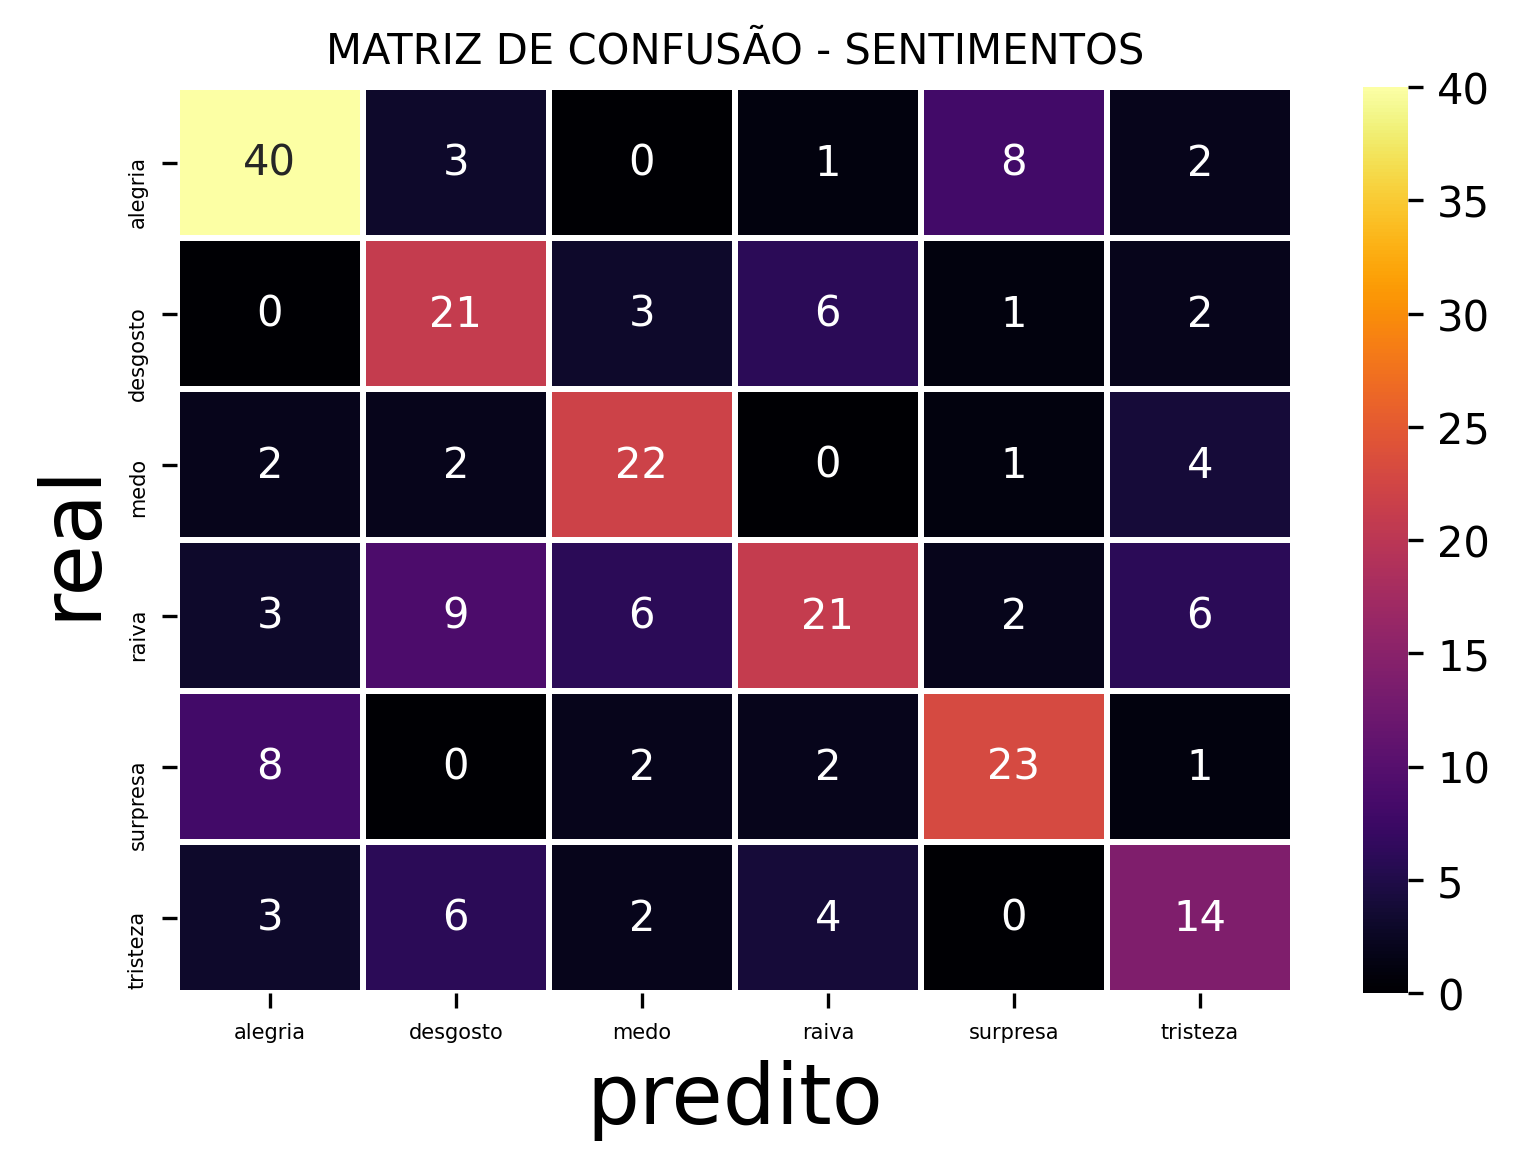

In [26]:
plt.figure(dpi=300)
plt.title('MATRIZ DE CONFUSÃO - SENTIMENTOS',fontsize=10)
sns.heatmap(confusion_matrix(d_teste['TESTE'],d_teste['PRED']),annot=True,cmap='inferno',lw=1,annot_kws={"size":10})
plt.xticks([0.5,1.5,2.5,3.5,4.5,5.5],['alegria','desgosto','medo','raiva','surpresa','tristeza'],fontsize=5)
plt.yticks([0.5,1.5,2.5,3.5,4.5,5.5],['alegria','desgosto','medo','raiva','surpresa','tristeza'],fontsize=5)
plt.xlabel('predito',fontsize=20)
plt.ylabel('real',fontsize=20)

In [43]:
21/(3+9+6+2+6+21)

0.44680851063829785

# verificar em 2D

In [32]:
from sklearn.manifold import TSNE

In [37]:
X = matriz_sentimentos
y=sentimentos['sentimento'].values
tse=TSNE(n_components=2, perplexity=10,n_iter=20000,init='random',random_state=42)
X_tse=tse.fit_transform(X)

/home/jlbdearaujo/.local/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


In [38]:
sentimentos['sentimento'].unique()

array(['alegria', 'desgosto', 'medo', 'raiva', 'surpresa', 'tristeza'],
      dtype=object)

In [39]:
cores=["blue","red","yellow",'green','gray','orange']
dic=dict(zip(sentimentos['sentimento'].unique(),cores))
listacor=[dic[v] for v in y]

In [42]:
dic

{'alegria': 'blue',
 'desgosto': 'red',
 'medo': 'yellow',
 'raiva': 'green',
 'surpresa': 'gray',
 'tristeza': 'orange'}

([], [])

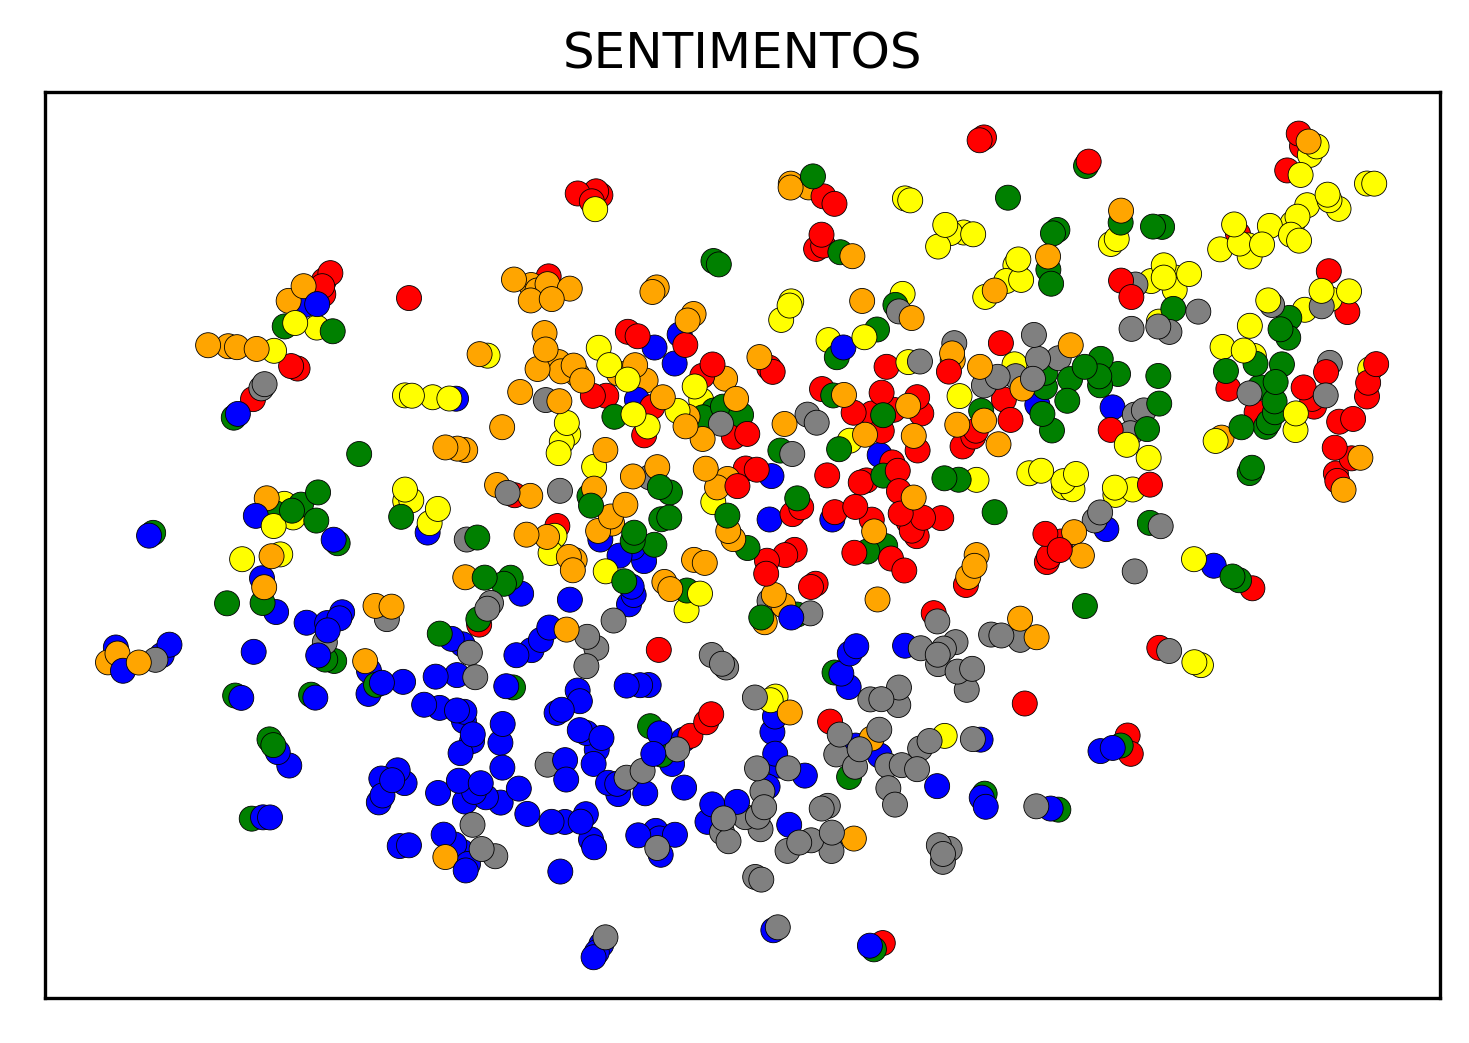

In [41]:
plt.figure(dpi=300)
plt.title("SENTIMENTOS")
plt.scatter(X_tse[:,0],X_tse[:,1],c=listacor,edgecolors="black",lw=0.2)
plt.xticks([],[])
plt.yticks([],[])

# Atualizar sentimentos

In [49]:
sentimentos['sentimento'].unique()

array(['alegria', 'desgosto', 'medo', 'raiva', 'surpresa', 'tristeza'],
      dtype=object)

In [50]:
dicmod={'alegria': 'POSITIVO', 'desgosto':'NEGATIVO', 'medo':'NEGATIVO', 'raiva':'NEGATIVO', 'surpresa': 'POSITIVO', 'tristeza':'NEGATIVO'}

In [52]:
sentimentos['SENTIMENTO_ATUALIZADO']=sentimentos.sentimento.map(dicmod)

In [53]:
sentimentos['SENTIMENTO_ATUALIZADO'].value_counts()

SENTIMENTO_ATUALIZADO
NEGATIVO    486
POSITIVO    280
Name: count, dtype: int64

In [54]:
X_train, X_test, y_train, y_test= train_test_split(matriz_sentimentos, sentimentos['SENTIMENTO_ATUALIZADO'].values,test_size=0.3, random_state = 42)
clf = LogisticRegression(max_iter=10000,random_state=42).fit(X_train, y_train)

y_pred=clf.predict(X_test)

print("Acurácia: ", accuracy_score(y_test, y_pred))
print("\nF1-Score:", f1_score(y_test, y_pred, average='weighted'))

Acurácia:  0.8739130434782608

F1-Score: 0.8740353877003161


In [55]:
d_teste=pd.DataFrame({'TESTE':y_test,'PRED':y_pred})
d_teste

,TESTE,PRED
0,POSITIVO,POSITIVO
1,NEGATIVO,NEGATIVO
2,NEGATIVO,NEGATIVO
3,POSITIVO,POSITIVO
4,NEGATIVO,NEGATIVO
...,...,...
225,NEGATIVO,NEGATIVO
226,NEGATIVO,NEGATIVO
227,NEGATIVO,NEGATIVO
228,NEGATIVO,POSITIVO


In [57]:
print('POSITIVO',len(d_teste[(d_teste['TESTE']=='POSITIVO')&(d_teste['PRED']=='POSITIVO')]) )
print('NEGATIVO',len(d_teste[(d_teste['TESTE']=='NEGATIVO')&(d_teste['PRED']=='NEGATIVO')]) )


POSITIVO 76
NEGATIVO 125


Text(137.16666666666669, 0.5, 'real')

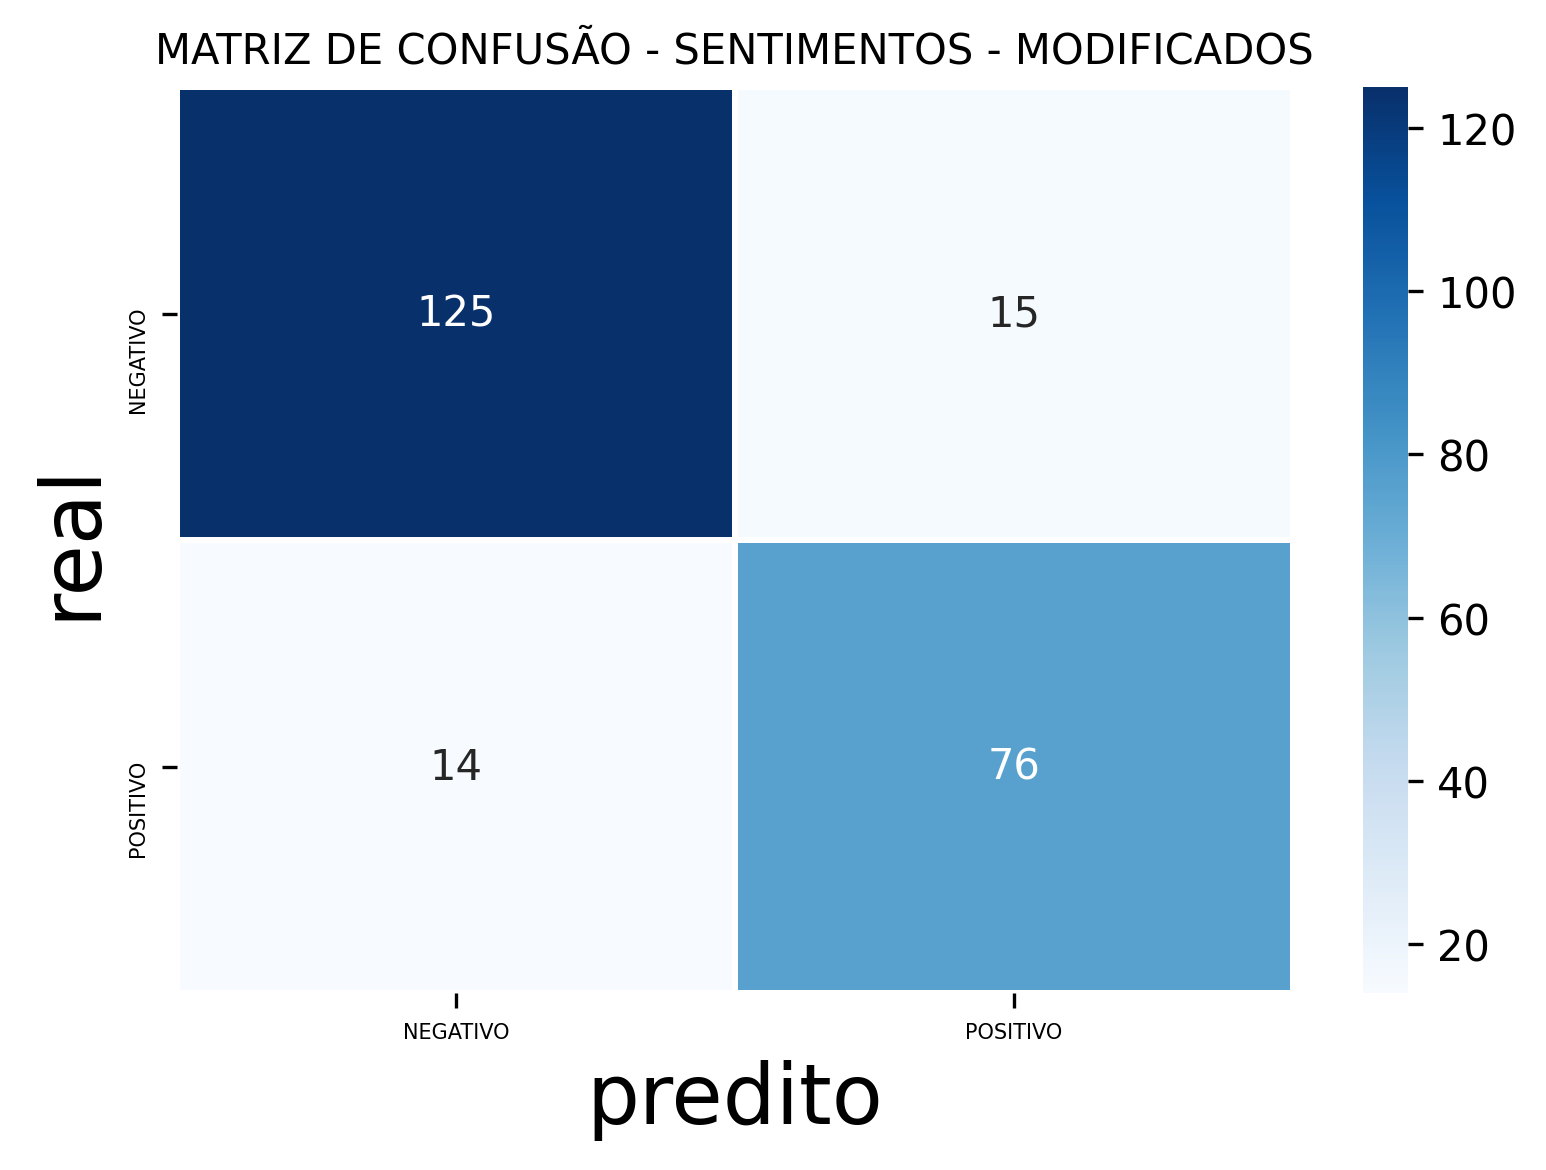

In [62]:
plt.figure(dpi=300)
plt.title('MATRIZ DE CONFUSÃO - SENTIMENTOS - MODIFICADOS',fontsize=10)
sns.heatmap(confusion_matrix(d_teste['TESTE'],d_teste['PRED']),annot=True,cmap='Blues',lw=1,annot_kws={"size":10},fmt='g')
plt.xticks([0.5,1.5],['NEGATIVO','POSITIVO'],fontsize=5)
plt.yticks([0.5,1.5],['NEGATIVO','POSITIVO'],fontsize=5)
plt.xlabel('predito',fontsize=20)
plt.ylabel('real',fontsize=20)

In [63]:
res_sen_byd=clf.predict(model.encode(df[df.MARCA=='BYD'].TEXTO.values))
pd.Series(res_sen_byd).value_counts(normalize=True)

POSITIVO    0.58209
NEGATIVO    0.41791
Name: proportion, dtype: float64

In [64]:
d_byd=pd.DataFrame({'TEXTO':df[df.MARCA=='BYD'].TEXTO.values,'SENTIMENTO':res_sen_byd})
d_byd

,TEXTO,SENTIMENTO
0,O caminhão BYD eT18 100% elétrico combina 245 ...,POSITIVO
1,A BYD possui diversos modelos de empilhadeiras...,NEGATIVO
2,Com espaço interno otimizado e recarga rápida ...,POSITIVO
3,Com capacidade para 25 toneladas e recarga com...,POSITIVO
4,A BYD celebra o Dia do Cliente valorizando cad...,NEGATIVO
...,...,...
196,"Os carregadores BYD-EVC-2SXM60 (60 Kw), EVC-2S...",NEGATIVO
197,"Pensado para o futuro, o BYD Green Tug é total...",POSITIVO
198,"Com os caminhões BYD, você tem mais tempo na e...",NEGATIVO
199,A BYD reconhece o trabalho e a habilidade do o...,POSITIVO


In [66]:
d_byd.SENTIMENTO.value_counts()

SENTIMENTO
POSITIVO    117
NEGATIVO     84
Name: count, dtype: int64

In [65]:
d_byd[d_byd.SENTIMENTO=='NEGATIVO']

,TEXTO,SENTIMENTO
1,A BYD possui diversos modelos de empilhadeiras...,NEGATIVO
4,A BYD celebra o Dia do Cliente valorizando cad...,NEGATIVO
8,A BYD foi finalista da edição 2023 do Prêmio A...,NEGATIVO
9,Hoje é celebrado o Dia da Árvore! 🌲\n\nA BYD t...,NEGATIVO
12,"Neste Dia Nacional do Trânsito, a BYD reforça ...",NEGATIVO
...,...,...
188,Com zero emissão de carbono e funcionamento su...,NEGATIVO
191,Otimize o espaço de armazenamento da sua opera...,NEGATIVO
192,A BYD já entregou mais de 105 mil ônibus elétr...,NEGATIVO
196,"Os carregadores BYD-EVC-2SXM60 (60 Kw), EVC-2S...",NEGATIVO


In [68]:
d_byd[d_byd.SENTIMENTO=='NEGATIVO'].TEXTO.values[3]

'Hoje é celebrado o Dia da Árvore! 🌲\n\nA BYD trabalha pela melhoria na qualidade de vida de toda a população. Por isso, reforça a importância da eletrificação na mobilidade urbana nas grandes cidades brasileiras.\n\nPor ano, cada ônibus da BYD evita a emissão de 125 mil kg de CO2, o equivalente ao plantio de 892 árvores.\n\nDessa forma, a BYD reforça sua missão de reduzir em 1°C a temperatura do planeta terra. ☀️🌎\n\n#BYD #BYDBrasil #DiadaArvore #Arvore'